# Exploring Judge Nationality Patterns

This notebook is a small example of the kind of analysis `cleanskate` makes possible once protocol scores and officials panels live in the same dataset.

Let's explore how judge nationality affects the scores. When a judge and skater/team share a nationality, how does that judge's mark compare with the rest of the panel on the same element or component? This is exploratory, not a causal model, but it is a useful way to show how the tables fit together.


## Load the officials panel

A judge-bias analysis has an awkward first step: the scores and the officials panel live on different protocol pages. `cleanskate` has already parsed both, so we can start by loading the segment officials table and keeping only judges.


In [24]:
import matplotlib as mpl
import numpy as np
import pandas as pd
import seaborn as sns

from cleanskate import Dataset

mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False

ds = Dataset(version="latest")

panel = ds.load_segment_officials()
judges = panel[panel["role"].str.startswith("Judge", na=False)].copy()

judges.head()


,event_label,segment_label,role,panel_position,name,nation
4,International Cranberry Cup 2025,Men SP,Judge No.1,1.0,Lise Rosto JENSEN,NOR
5,International Cranberry Cup 2025,Men SP,Judge No.2,2.0,Chihee RHEE,KOR
6,International Cranberry Cup 2025,Men SP,Judge No.3,3.0,Lorrie PARKER,USA
7,International Cranberry Cup 2025,Men SP,Judge No.4,4.0,Cynthia BENSON,CAN
8,International Cranberry Cup 2025,Men SP,Judge No.5,5.0,Saara EHALT,FIN


Some protocols list every judge's nationality as `ISU`, which is not very helpful for this question. Before dropping those rows, let's see how much of the panel is affected.


In [25]:
judges["nation"].value_counts(dropna=False).head(10)


nation
ISU    2355
USA     549
CAN     457
JPN     375
ITA     339
FRA     316
GER     271
KOR     208
CHN     180
RUS     178
Name: count, dtype: int64

When the same judge appears elsewhere with a country code, we can use that other appearance to recover a conservative inferred nationality. Judges who only ever appear as `ISU` stay out of this example.


In [26]:
known_judges = judges[judges["nation"].ne("ISU")].copy()
isu_judges = judges[judges["nation"].eq("ISU")].drop(columns="nation")

inferred_nations = known_judges[["name", "nation"]].drop_duplicates()
inferred_isu_judges = isu_judges.merge(inferred_nations, on="name", how="inner")

judges = pd.concat([known_judges, inferred_isu_judges], ignore_index=True)
judges = judges.dropna(subset=["panel_position"])
judges["judge_index"] = judges["panel_position"].astype(int) - 1

pd.DataFrame(
    {
        "panel_rows_with_known_or_inferred_nation": [len(judges)],
        "unique_judges": [judges["name"].nunique()],
        "unique_nations": [judges["nation"].nunique()],
    }
)


,panel_rows_with_known_or_inferred_nation,unique_judges,unique_nations
0,6936,446,50


We can merge the judge information with the results based on a combination of three columns: event, segment, and the judge's position in the score list (zero-based to be Python-friendly).


In [27]:
judge_panel = judges[
    ["event_label", "segment_label", "name", "nation", "judge_index"]
].rename(columns={"name": "judge_name", "nation": "judge_nation"})

judge_panel.head()


,event_label,segment_label,judge_name,judge_nation,judge_index
0,International Cranberry Cup 2025,Men SP,Lise Rosto JENSEN,NOR,0
1,International Cranberry Cup 2025,Men SP,Chihee RHEE,KOR,1
2,International Cranberry Cup 2025,Men SP,Lorrie PARKER,USA,2
3,International Cranberry Cup 2025,Men SP,Cynthia BENSON,CAN,3
4,International Cranberry Cup 2025,Men SP,Saara EHALT,FIN,4


## Compare each judge to the rest of the panel

For each element, we want to ask: what did this judge give, and what did everyone else give? The elements table has the full list of judges marks, enabling us to make the comparison.

In [28]:
elements = ds.load_elements()
elements = elements[elements["scored_element"].eq(True)].copy()

elements[["event_label", "segment_label", "name", "noc", "element_code", "judge_scores"]].head()


,event_label,segment_label,name,noc,element_code,judge_scores
0,International Cranberry Cup 2025,Men SP,Jimmy MA,USA,4T,"[2.0, 3.0, 3.0, 2.0, 2.0, 3.0, 3.0]"
1,International Cranberry Cup 2025,Men SP,Jimmy MA,USA,3A,"[-2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -1.0]"
2,International Cranberry Cup 2025,Men SP,Jimmy MA,USA,FCSp3,"[2.0, 1.0, 0.0, 1.0, 1.0, 1.0, 2.0]"
3,International Cranberry Cup 2025,Men SP,Jimmy MA,USA,3Lz+3T,"[-4.0, -4.0, -4.0, -4.0, -5.0, -4.0, -5.0]"
4,International Cranberry Cup 2025,Men SP,Jimmy MA,USA,StSq3,"[3.0, 3.0, 3.0, 1.0, 4.0, 2.0, 3.0]"


Now we attach the judges for the matching event and segment. This expands each element row once per judge on the panel.


In [29]:
element_scores = elements.merge(
    judge_panel,
    on=["event_label", "segment_label"],
    how="inner",
)

element_scores = element_scores[
    element_scores.apply(lambda row: row["judge_index"] < len(row["judge_scores"]), axis=1)
].copy()

element_scores[[
    "event_label",
    "segment_label",
    "name",
    "noc",
    "judge_name",
    "judge_nation",
    "element_code",
    "judge_scores",
]].head()


,event_label,segment_label,name,noc,judge_name,judge_nation,element_code,judge_scores
0,International Cranberry Cup 2025,Men SP,Jimmy MA,USA,Lise Rosto JENSEN,NOR,4T,"[2.0, 3.0, 3.0, 2.0, 2.0, 3.0, 3.0]"
1,International Cranberry Cup 2025,Men SP,Jimmy MA,USA,Chihee RHEE,KOR,4T,"[2.0, 3.0, 3.0, 2.0, 2.0, 3.0, 3.0]"
2,International Cranberry Cup 2025,Men SP,Jimmy MA,USA,Lorrie PARKER,USA,4T,"[2.0, 3.0, 3.0, 2.0, 2.0, 3.0, 3.0]"
3,International Cranberry Cup 2025,Men SP,Jimmy MA,USA,Cynthia BENSON,CAN,4T,"[2.0, 3.0, 3.0, 2.0, 2.0, 3.0, 3.0]"
4,International Cranberry Cup 2025,Men SP,Jimmy MA,USA,Saara EHALT,FIN,4T,"[2.0, 3.0, 3.0, 2.0, 2.0, 3.0, 3.0]"


The score list is ordered by panel position. Once the judge index is attached, we can pull out that judge's mark and compare it with the mean of the other judges on the same element.


In [30]:
def judge_score(row):
    return row["judge_scores"][row["judge_index"]]


def other_judges_mean(row):
    return np.mean([score for index, score in enumerate(row["judge_scores"]) if index != row["judge_index"]])


In [31]:
element_scores["judge_score"] = element_scores.apply(judge_score, axis=1)
element_scores["other_judges_mean_score"] = element_scores.apply(other_judges_mean, axis=1)
element_scores["judge_difference"] = element_scores["judge_score"] - element_scores["other_judges_mean_score"]
element_scores["nationality_match"] = element_scores["noc"].eq(element_scores["judge_nation"])

element_scores[[
    "name",
    "noc",
    "judge_name",
    "judge_nation",
    "element_code",
    "judge_score",
    "other_judges_mean_score",
    "judge_difference",
    "nationality_match",
]].head()


,name,noc,judge_name,judge_nation,element_code,judge_score,other_judges_mean_score,judge_difference,nationality_match
0,Jimmy MA,USA,Lise Rosto JENSEN,NOR,4T,2.0,2.666667,-0.666667,False
1,Jimmy MA,USA,Chihee RHEE,KOR,4T,3.0,2.500000,0.500000,False
2,Jimmy MA,USA,Lorrie PARKER,USA,4T,3.0,2.500000,0.500000,True
3,Jimmy MA,USA,Cynthia BENSON,CAN,4T,2.0,2.666667,-0.666667,False
4,Jimmy MA,USA,Saara EHALT,FIN,4T,2.0,2.666667,-0.666667,False


## Element-score differences by nationality match

Now we can ask the descriptive version of the question: are matched-nationality marks higher, lower, or about the same as the rest of the panel? 

In [32]:
element_summary = (
    element_scores.groupby("nationality_match", as_index=False)
    .agg(
        rows=("judge_difference", "size"),
        mean_difference=("judge_difference", "mean"),
        median_difference=("judge_difference", "median"),
    )
)

element_summary


,nationality_match,rows,mean_difference,median_difference
0,False,792359,-0.019499,0.000000
1,True,69560,0.199767,0.166667


In this snapshot, matched-nationality element marks average about **0.20 GOE points above** the rest of the panel, while non-matched marks average about **0.02 points below**. Put another way, the matched group is about **0.22 GOE points higher** on average. The median gap is smaller, about **0.17 GOE points**, suggesting there may be some outliers.


We can also visualize the full distribution of differences with a boxplot.

Text(0, 0.5, "Judge score minus other judges' mean")

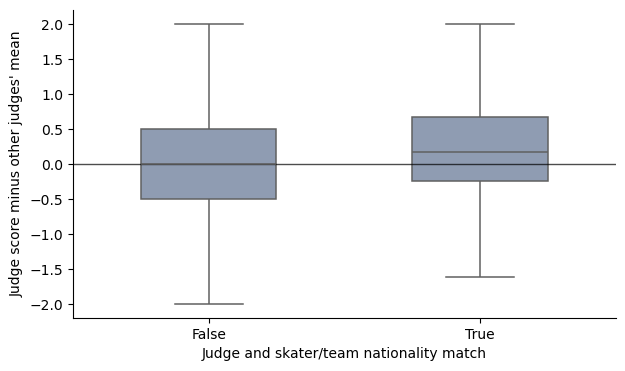

In [38]:
mpl.pyplot.figure(figsize=(7, 4))
ax = sns.boxplot(
    data=element_scores,
    x="nationality_match",
    y="judge_difference",
    width=0.5,
    fliersize=2,
    linewidth=1.1,
    showfliers=False,
    color="#899BB8",
)
ax.axhline(0, color="black", linewidth=1, alpha=0.7)
ax.set_xlabel("Judge and skater/team nationality match")
ax.set_ylabel("Judge score minus other judges' mean")


## Repeat the comparison for program components

We can also run the same analysis for program component scores.

In [34]:
components = ds.load_program_components()

components[["event_label", "segment_label", "name", "noc", "component_name", "judge_scores"]].head()


,event_label,segment_label,name,noc,component_name,judge_scores
0,International Cranberry Cup 2025,Men SP,Jimmy MA,USA,Composition,"[7.5, 8.5, 8.0, 7.25, 6.5, 7.0, 7.0]"
1,International Cranberry Cup 2025,Men SP,Jimmy MA,USA,Presentation,"[7.5, 8.25, 8.25, 7.0, 7.0, 7.5, 7.5]"
2,International Cranberry Cup 2025,Men SP,Jimmy MA,USA,Skating Skills,"[7.75, 8.25, 7.75, 7.25, 7.25, 7.25, 7.5]"
3,International Cranberry Cup 2025,Men SP,Jacob SANCHEZ,USA,Composition,"[6.75, 6.5, 7.75, 7.25, 8.25, 7.5, 6.5]"
4,International Cranberry Cup 2025,Men SP,Jacob SANCHEZ,USA,Presentation,"[7.0, 6.75, 8.0, 7.5, 7.75, 7.25, 6.5]"


In [35]:
component_scores = components.merge(
    judge_panel,
    on=["event_label", "segment_label"],
    how="inner",
)

component_scores = component_scores[
    component_scores.apply(lambda row: row["judge_index"] < len(row["judge_scores"]), axis=1)
].copy()
component_scores["judge_score"] = component_scores.apply(judge_score, axis=1)
component_scores["other_judges_mean_score"] = component_scores.apply(other_judges_mean, axis=1)
component_scores["judge_difference"] = component_scores["judge_score"] - component_scores["other_judges_mean_score"]
component_scores["nationality_match"] = component_scores["noc"].eq(component_scores["judge_nation"])

component_scores[[
    "name",
    "noc",
    "judge_name",
    "judge_nation",
    "component_name",
    "judge_difference",
    "nationality_match",
]].head()


,name,noc,judge_name,judge_nation,component_name,judge_difference,nationality_match
0,Jimmy MA,USA,Lise Rosto JENSEN,NOR,Composition,0.125000,False
1,Jimmy MA,USA,Chihee RHEE,KOR,Composition,1.291667,False
2,Jimmy MA,USA,Lorrie PARKER,USA,Composition,0.708333,True
3,Jimmy MA,USA,Cynthia BENSON,CAN,Composition,-0.166667,False
4,Jimmy MA,USA,Saara EHALT,FIN,Composition,-1.041667,False


And the same summary table gives us a compact component-level comparison.


In [ ]:
component_summary = (
    component_scores.groupby("nationality_match", as_index=False)
    .agg(
        rows=("judge_difference", "size"),
        mean_difference=("judge_difference", "mean"),
        median_difference=("judge_difference", "median"),
    )
)

component_summary


,nationality_match,rows,mean_difference,median_difference
0,False,344165,-0.015848,0.000000
1,True,30503,0.163788,0.166667


In this snapshot, matched-nationality component marks average about **0.16 points above** the rest of the panel, while non-matched marks average about **0.02 points below**. That is a gap of about **0.18 component points**. The median gap is about **0.17 points**.

We can break this down further by type of component.


Text(0, 0.5, "Component score minus other judges' mean")

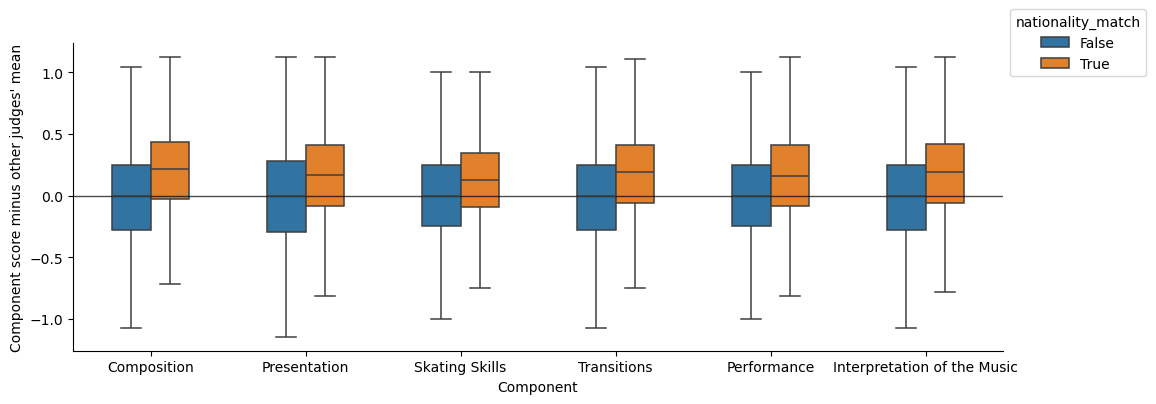

In [53]:
mpl.pyplot.figure(figsize=(12, 4))
ax = sns.boxplot(
    data=component_scores,
    x="component_name",
    y="judge_difference",
    hue="nationality_match",
    width=0.5,
    fliersize=2,
    linewidth=1.1,
    showfliers=False
)
ax.axhline(0, color="black", linewidth=1, alpha=0.7)
sns.move_legend(ax, "center left", bbox_to_anchor=(1, 1))
ax.set_xlabel("Component")
ax.set_ylabel("Component score minus other judges' mean")


The same pattern is seen in all categories, but there are slight differences in magnitude. Composition has the largest average difference (**0.216 component points**) while skating skills has the lowest (**0.139 component points**).

In [50]:
per_component_summary = (
    component_scores.groupby(["component_name", "nationality_match"], as_index=False)
    .agg(
        rows=("judge_difference", "size"),
        mean_difference=("judge_difference", "mean"),
        median_difference=("judge_difference", "median"),
    )
)
per_component_summary

,component_name,nationality_match,rows,mean_difference,median_difference
0,Composition,False,92673,-0.016826,0.000000
1,Composition,True,8039,0.199589,0.214286
2,Interpretation of the Music,False,33073,-0.019367,0.000000
3,Interpretation of the Music,True,3193,0.167367,0.187500
4,Performance,False,33073,-0.015053,0.000000
5,Performance,True,3193,0.148343,0.156250
6,Presentation,False,59600,-0.016635,0.000000
7,Presentation,True,4846,0.166018,0.166667
8,Skating Skills,False,92673,-0.012779,0.000000
9,Skating Skills,True,8039,0.126311,0.125000


## Country patterns

We can take this a step further and look at whether there are patterns of countries that award each other higher scores (e.g. do Canadian judges score American skaters highly?). 

To visualize this, we calculate the average panel-adjusted score for each observed set of judge/skater nationalities. Some pairings are very rare, so a threshold is useful to ensure we only look at countries with sufficient data.

In [ ]:
MIN_COUNTRY_PAIRINGS = 20

nationality_patterns = component_scores.groupby(['judge_nation', 'noc'], as_index=False)['judge_difference'].agg(mean_difference=np.mean, count=len)
nationality_patterns = nationality_patterns[ nationality_patterns['count'] >= 100 ]

def filter_countries(df: pd.DataFrame) -> pd.DataFrame:
    """
    Restrict to countries that are observed in sufficient pairings with other countries
    """
    judge_counts = df.groupby('judge_nation').size()
    noc_counts = df.groupby('noc').size()

    countries_to_keep = set(judge_counts[ judge_counts >= MIN_COUNTRY_PAIRINGS].index) & set(noc_counts[ noc_counts >= MIN_COUNTRY_PAIRINGS].index)

    return df[ df['judge_nation'].isin(countries_to_keep) & df['noc'].isin(countries_to_keep)]

nationality_patterns = filter_countries(nationality_patterns)
nationality_patterns

,judge_nation,noc,mean_difference,count
27,AUS,AUS,0.046644,546
35,AUS,CAN,-0.003296,1258
37,AUS,CHN,0.043835,558
40,AUS,CZE,0.038633,155
42,AUS,ESP,0.132944,133
...,...,...,...,...
2639,USA,RUS,-0.035098,2215
2643,USA,SUI,-0.058273,432
2645,USA,SWE,-0.028743,260
2650,USA,UKR,-0.085620,487


We can visualize the scores in a heatmap.

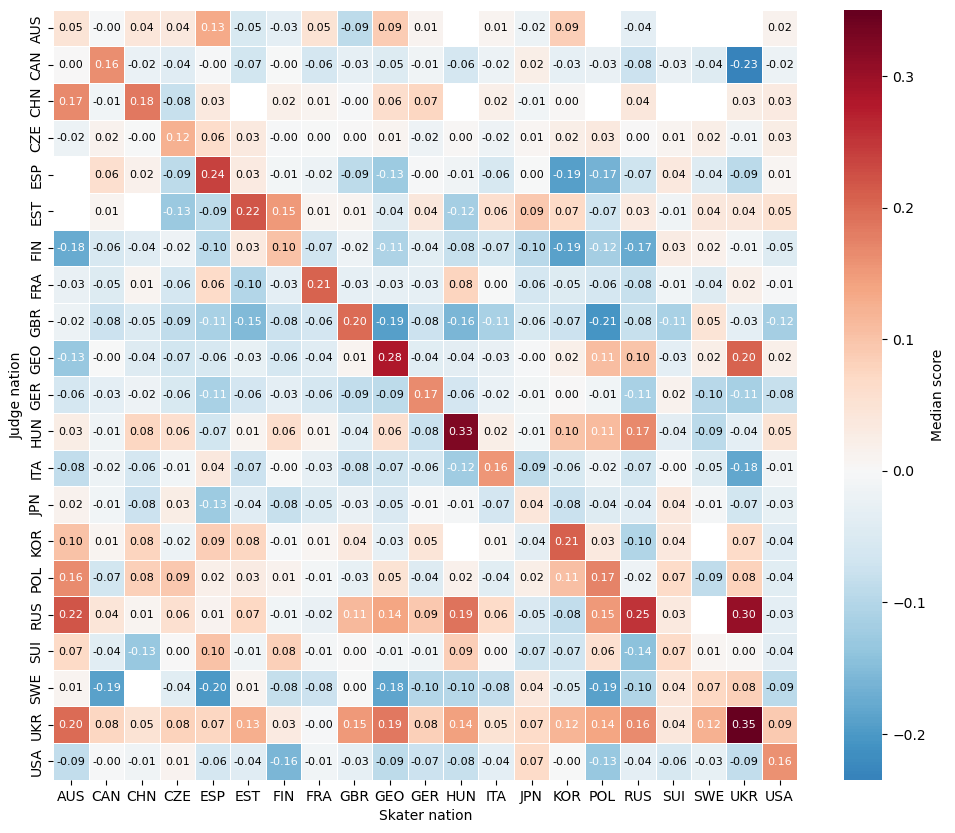

In [114]:
def plot_score_heatmap(df: pd.DataFrame):
    heatmap_data = df.pivot(
        index="judge_nation",
        columns="noc",
        values="mean_difference"
        )

    mpl.pyplot.figure(figsize=(12, 10))
    ax = sns.heatmap(
        heatmap_data,
        cmap="RdBu_r",
        center=0,
        linewidths=0.5,
        linecolor="white",
        annot=True,
        fmt=".2f",
        annot_kws={
            "size": 8,
            "ha": "center",
            "va": "center"
        },
        cbar_kws={"label": "Median score"}
    )

    # adjust text color based on background
    for text in ax.texts:
        value = float(text.get_text())
        text.set_color("white" if abs(value) > 0.1 else "black")
        
    ax.set_xlabel('Skater nation')
    ax.set_ylabel("Judge nation")

plot_score_heatmap(nationality_patterns)


The Canadians do not appear to harbour any particular preferences for American skaters, but some other patterns emerge. In particular, former Soviet bloc Georgia, Hungary, Russia, and Ukraine tend to rate each other highly. The Russian and Hungarian judges also tend to be generous across the board. 

Japan deserves a special shoutout for being the most consistent when scoring their own skaters. Their average difference against the rest of the panel is only 0.04 component points.

This analysis used the component scores. We can repeat it for the element scores. 

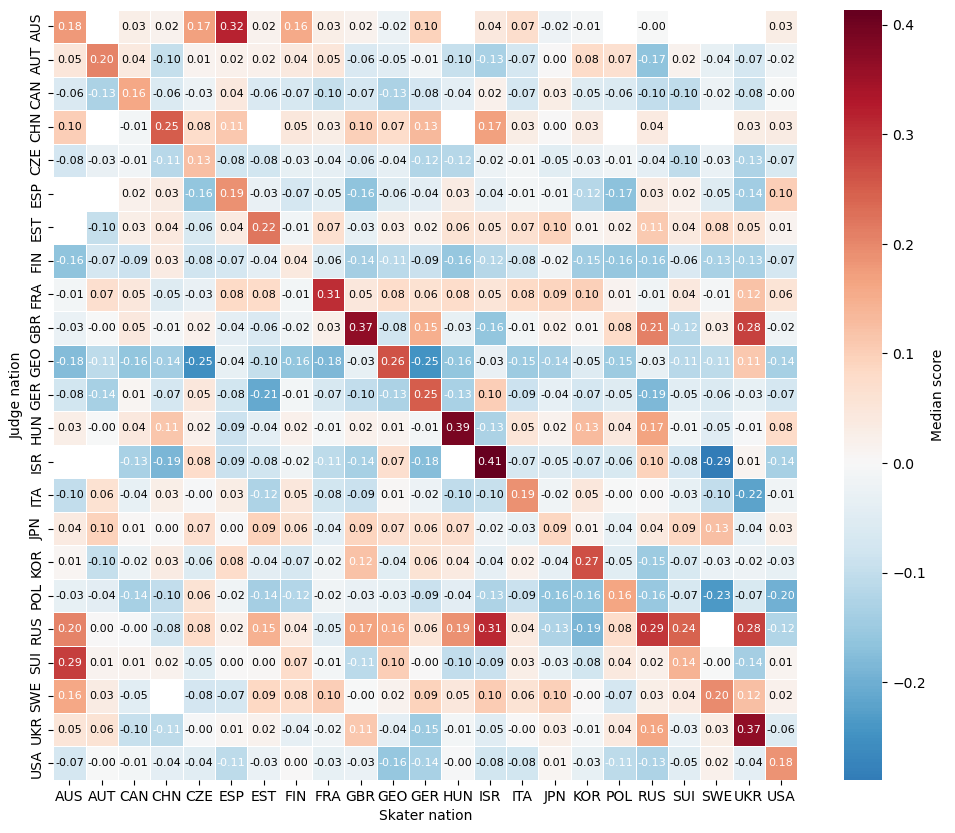

In [ ]:
nationality_patterns_elements = element_scores.groupby(['judge_nation', 'noc'], as_index=False)['judge_difference'].agg(mean_difference=np.mean, count=len)
nationality_patterns_elements = nationality_patterns_elements[ nationality_patterns_elements['count'] >=  200 ]

nationality_patterns_elements = filter_countries(nationality_patterns_elements)

plot_score_heatmap(nationality_patterns_elements)

## Caveats

This is an initial analysis with several caveats. The approach does not adjust for skater quality, event, discipline, home-country effects or panel composition. It also ignores how many different judges there are from a country. Trends observed across many judges are more believable than ones driven by a few judges. 